<div dir="rtl" style="text-align:center; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:28px; font-weight:bold; margin:20px 0; color:#2e86de;">
تحلیل‌های آماری
</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Divar.csv")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5744\1381234337.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Divar.csv")


<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۱: رسم توزیع آگهی‌های موجود در دسته‌های مختلف برای دسته‌بندی سطح دو و سطح سه
</div>

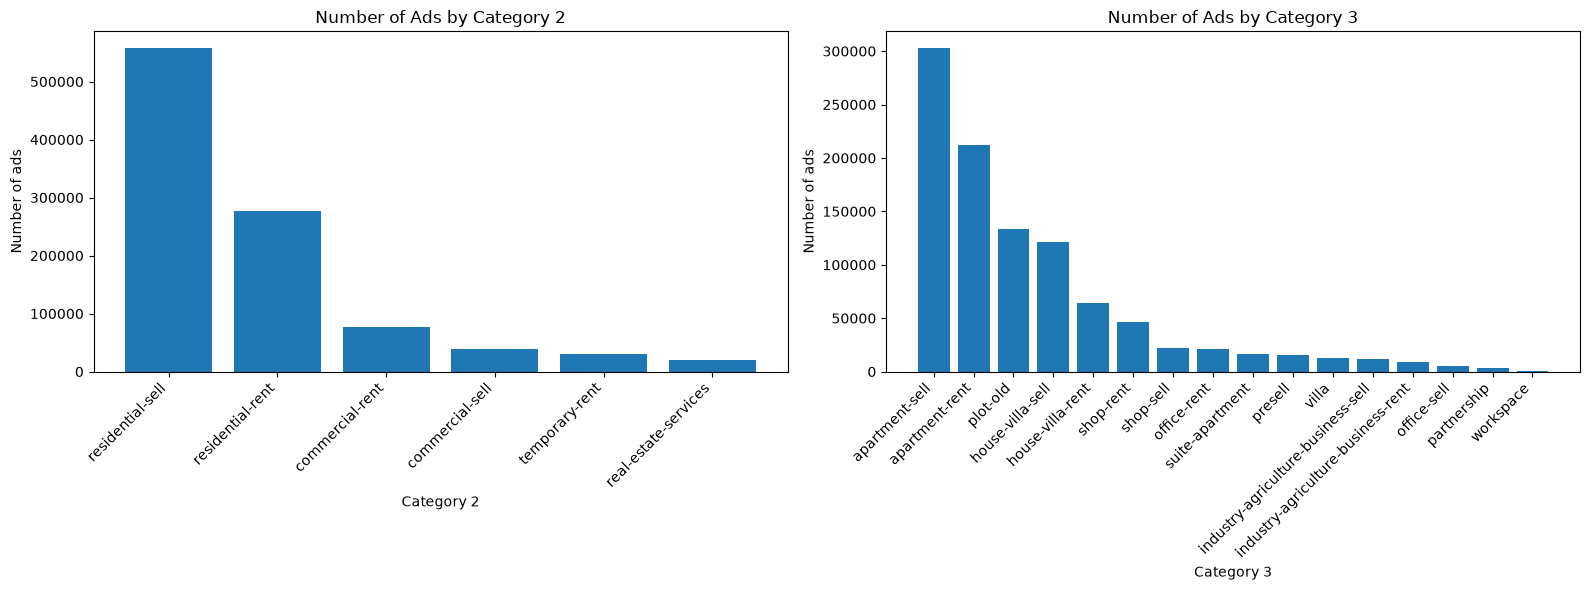

In [5]:
ad_count_by_cat2 = df['cat2_slug'].value_counts()
ad_count_by_cat3 = df['cat3_slug'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(ad_count_by_cat2.index, ad_count_by_cat2.values)
ax1.set_ylabel('Number of ads')
ax1.set_xlabel('Category 2')
ax1.set_title('Number of Ads by Category 2')

ax2.bar(ad_count_by_cat3.index, ad_count_by_cat3.values)
ax2.set_ylabel('Number of ads')
ax2.set_xlabel('Category 3')
ax2.set_title('Number of Ads by Category 3')

for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

for label in ax2.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
در هر دو نمودار، توزیع آگهی‌ها بین دسته‌های مختلف یکسان نیست. در سطح دوم، آگهی‌های فروش و اجاره مسکونی بیشترین فراوانی را دارند و در سطح سوم نیز فروش و اجاره آپارتمان در رتبه‌های اول قرار گرفته‌اند. این موضوع نشان‌دهنده‌ی تمرکز بخش عمده‌ای از داده‌ها بر بازار املاک مسکونی، به‌ویژه آپارتمان‌ها، است.
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۲: هیستوگرام سال ساخت
</div>

In [5]:
#Q2

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۳: بررسی تعداد آگهی‌های منتشر شده در ماه‌های مختلف را برای فروش و اجاره
</div>

برای این سوال ابتدا ستون تاریخ انتشار آگهی را به تاریخ شمسی تبدیل کرده‌ایم. سپس آگهی‌های املاک را بر مبنای فروش و اجاره و مسکونی و تجاری در چهار گروه دسته‌بندی و نمودار آن را رسم کردیم

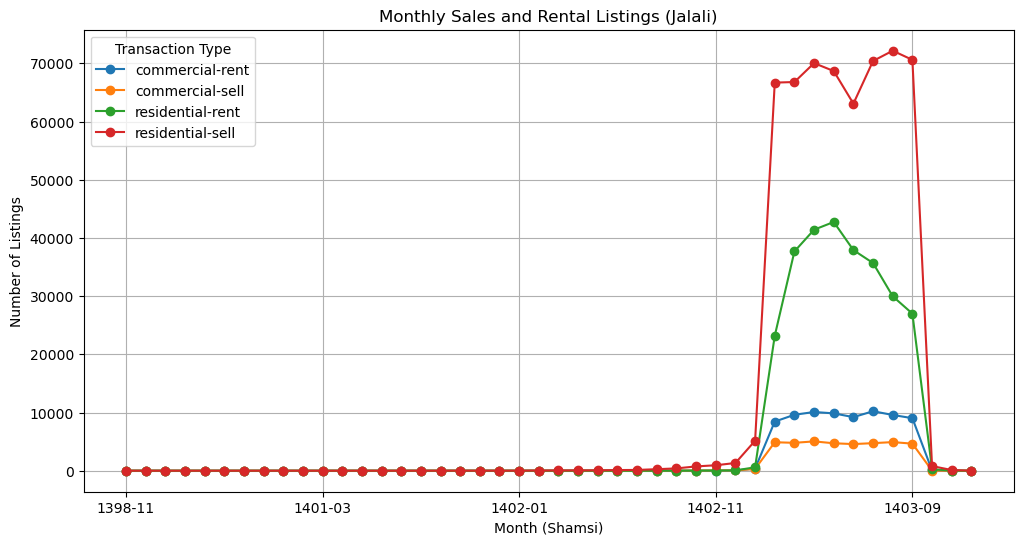

In [ ]:
import jdatetime

df = pd.read_csv("Divar.csv", low_memory=False)

#  تبدیل تاریخ به شمسی
df["created_at_month"] = pd.to_datetime(df["created_at_month"])

df["created_at_month_shamsi"] = df["created_at_month"].apply(
    lambda x: jdatetime.date.fromgregorian(date=x.date()).strftime("%Y-%m")
    if pd.notnull(x)
    else None
)

# گروه‌بندی
monthly_counts = (
    df[
        df["cat2_slug"].isin(
            [
                "residential-sell",
                "residential-rent",
                "commercial-rent",
                "commercial-sell",
            ]
        )
    ]
    .groupby(["created_at_month_shamsi", "cat2_slug"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

#print(monthly_counts)

#  رسم نمودار
monthly_counts.plot(kind="line", marker="o", figsize=(12, 6))

plt.title("Monthly Sales and Rental Listings (Jalali)")
plt.xlabel("Month (Shamsi)")
plt.ylabel("Number of Listings")
plt.grid(True)
plt.legend(title="Transaction Type")

plt.show()


یک بار هم آکهی‌های اجاره و فروش مسکونی و تجاری را با هم تجمیع کردیم و نمودار هر دو را رسم کردیم


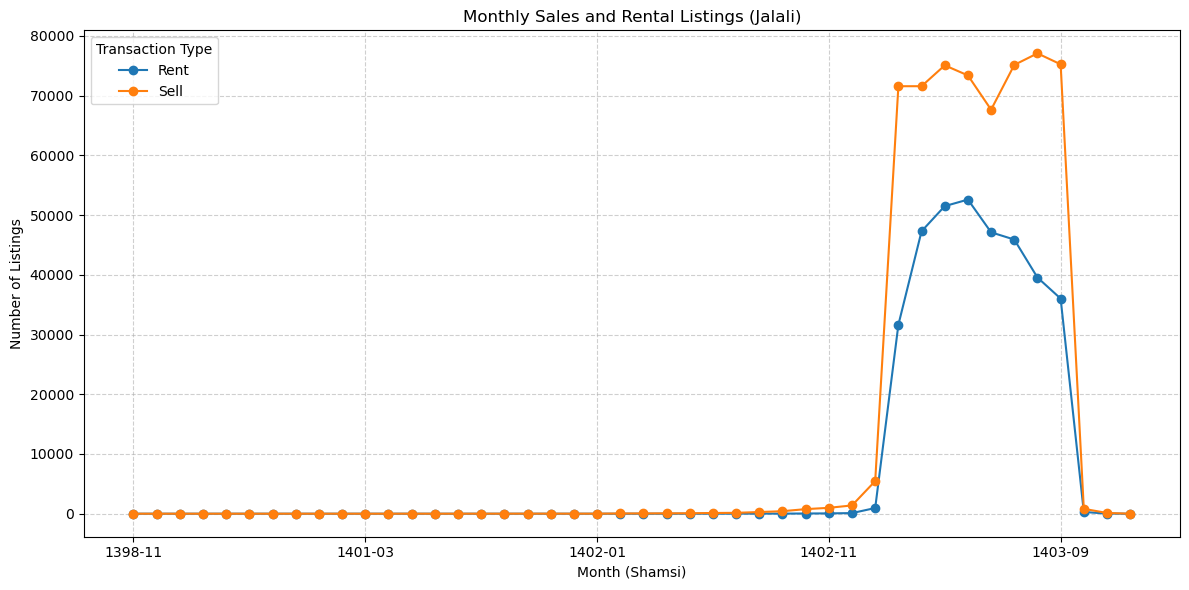

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import jdatetime

df = pd.read_csv("Divar.csv", low_memory=False)

#  فیلتر کردن داده‌ها
df_filtered = df[
    df["cat2_slug"].isin(
        [
            "residential-sell",
            "residential-rent",
            "commercial-rent",
            "commercial-sell",
        ]
    )
].copy()

#  ایجاد ستون نوع معامله
df_filtered["transaction_type"] = df_filtered["cat2_slug"].map(
    {
        "residential-sell": "Sell",
        "commercial-sell": "Sell",
        "residential-rent": "Rent",
        "commercial-rent": "Rent",
    }
)

#  تبدیل تاریخ میلادی به ماه شمسی
df_filtered["created_at_month"] = pd.to_datetime(
    df_filtered["created_at_month"]
)

df_filtered["created_at_month_shamsi"] = df_filtered["created_at_month"].apply(
    lambda x: jdatetime.date.fromgregorian(date=x.date()).strftime("%Y-%m")
    if pd.notnull(x)
    else None
)

# گروه‌بندی بر اساس ماه شمسی و نوع معامله
monthly_counts = (
    df_filtered.groupby(["created_at_month_shamsi", "transaction_type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

#print(monthly_counts)

#  رسم نمودار
ax = monthly_counts.plot(kind="line", marker="o", figsize=(12, 6))

ax.set_title("Monthly Sales and Rental Listings (Jalali)")
ax.set_xlabel("Month (Shamsi)")
ax.set_ylabel("Number of Listings")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(title="Transaction Type")
plt.tight_layout()
plt.show()

یک بار هم آکهی‌های اجاره و فروش مسکونی و تجاری را با هم تجمیع کردیم و نمودار هر دو را رسم کردیم

آگهی‌ها عمدتا مربوط به سال ۱۴۰۳ بودند. برای همین مجددا  نمودارها را از ابتدای سال ۱۴۰۳ رسم کردیم

cat2_slug                commercial-rent  commercial-sell  residential-rent  \
created_at_month_shamsi                                                       
1403-01                              365              312               587   
1403-02                             8444             4893             23189   
1403-03                             9615             4795             37680   
1403-04                            10089             5040             41414   
1403-05                             9857             4718             42742   
1403-06                             9209             4577             37910   
1403-07                            10223             4737             35683   
1403-08                             9581             4917             29970   
1403-09                             9027             4651             26993   

cat2_slug                residential-sell  
created_at_month_shamsi                    
1403-01                              5153 

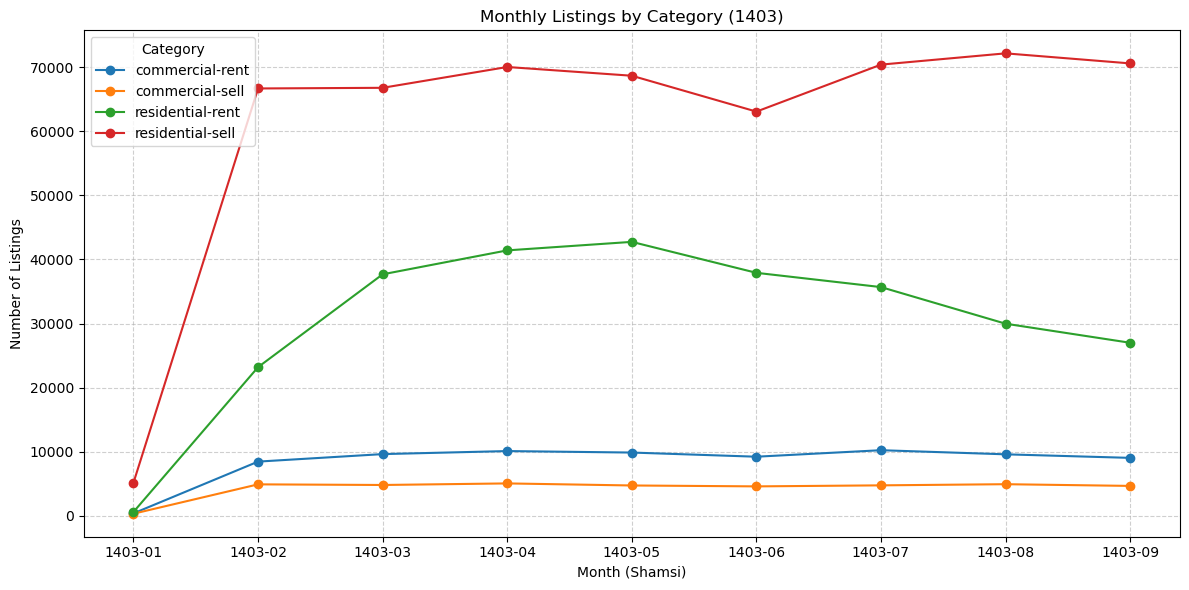

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import jdatetime

# تبدیل  تاریخ 
df["created_at_month"] = pd.to_datetime(df["created_at_month"])

#  فیلتر کردن بازه زمانی معتبر (حذف داده‌های پرت و بسیار کمِ قبل و بعد)
df_filtered = df[
    (df["created_at_month"] >= "2024-04-01")
    & (df["created_at_month"] <= "2024-12-01")
].copy()

#  تبدیل تاریخ میلادی به ماه شمسی
df_filtered["created_at_month_shamsi"] = df_filtered["created_at_month"].apply(
    lambda x: jdatetime.date.fromgregorian(date=x.date()).strftime("%Y-%m")
    if pd.notnull(x)
    else None
)

#  فیلتر دسته‌ها و گروه‌بندی بر اساس ماه شمسی
monthly_counts = (
    df_filtered[
        df_filtered["cat2_slug"].isin(
            [
                "residential-sell",
                "residential-rent",
                "commercial-rent",
                "commercial-sell",
            ]
        )
    ]
    .groupby(["created_at_month_shamsi", "cat2_slug"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print(monthly_counts)

#  رسم نمودار
monthly_counts.plot(kind="line", marker="o", figsize=(12, 6))

plt.title("Monthly Listings by Category (1403)")
plt.xlabel("Month (Shamsi)")
plt.ylabel("Number of Listings")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Category")
plt.tight_layout()

plt.show()

transaction_type          Rent   Sell
created_at_month_shamsi              
1403-01                    952   5465
1403-02                  31633  71581
1403-03                  47295  71584
1403-04                  51503  75079
1403-05                  52599  73392
1403-06                  47119  67652
1403-07                  45906  75146
1403-08                  39551  77085
1403-09                  36020  75250


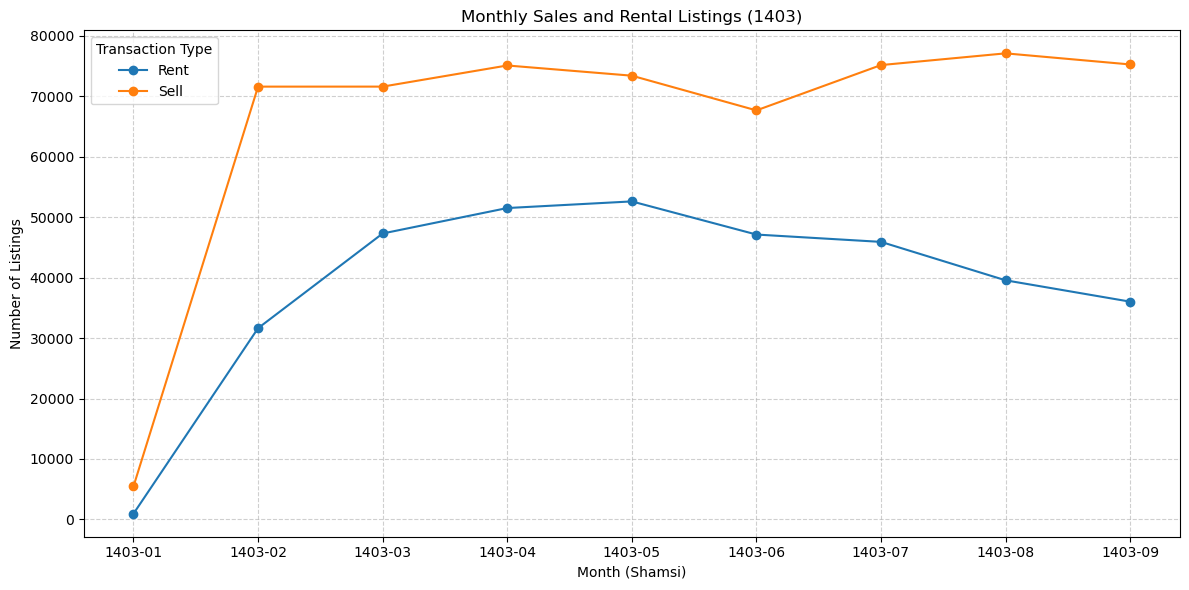

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import jdatetime

# تبدیل ستون تاریخ 
df["created_at_month"] = pd.to_datetime(df["created_at_month"])

#  فیلتر کردن بازه زمانی معتبر و دسته‌بندی‌های هدف
df_filtered = df[
    (df["created_at_month"] >= "2024-04-01")
    & (df["created_at_month"] <= "2024-12-01")
    & (
        df["cat2_slug"].isin(
            [
                "residential-sell",
                "residential-rent",
                "commercial-rent",
                "commercial-sell",
            ]
        )
    )
].copy()

#  ایجاد ستون نوع معامله (Rent / Sell)
df_filtered["transaction_type"] = df_filtered["cat2_slug"].map(
    {
        "residential-sell": "Sell",
        "commercial-sell": "Sell",
        "residential-rent": "Rent",
        "commercial-rent": "Rent",
    }
)

#  تبدیل تاریخ میلادی به ماه شمسی
df_filtered["created_at_month_shamsi"] = df_filtered["created_at_month"].apply(
    lambda x: jdatetime.date.fromgregorian(date=x.date()).strftime("%Y-%m")
    if pd.notnull(x)
    else None
)

#  گروه‌بندی بر اساس ماه شمسی و نوع معامله
monthly_counts = (
    df_filtered.groupby(["created_at_month_shamsi", "transaction_type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print(monthly_counts)

#  رسم نمودار
ax = monthly_counts.plot(kind="line", marker="o", figsize=(12, 6))

ax.set_title("Monthly Sales and Rental Listings (1403)")
ax.set_xlabel("Month (Shamsi)")
ax.set_ylabel("Number of Listings")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(title="Transaction Type")
plt.tight_layout()

plt.show()

 نمودارها نشان می‌دهد اجاره املاک مسکونی به طور خاص از ابتدای تابستان صعود قابل‌ توجهی است و این صعودی بودن تا تابستان ادامه دارد و در پاییز روند اجاره نزولی می‌شود

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
 سوال ۴: توزیع قیمت فروش‌ (price_value) برای دسته‌بندی‌های سطح سه
</div>

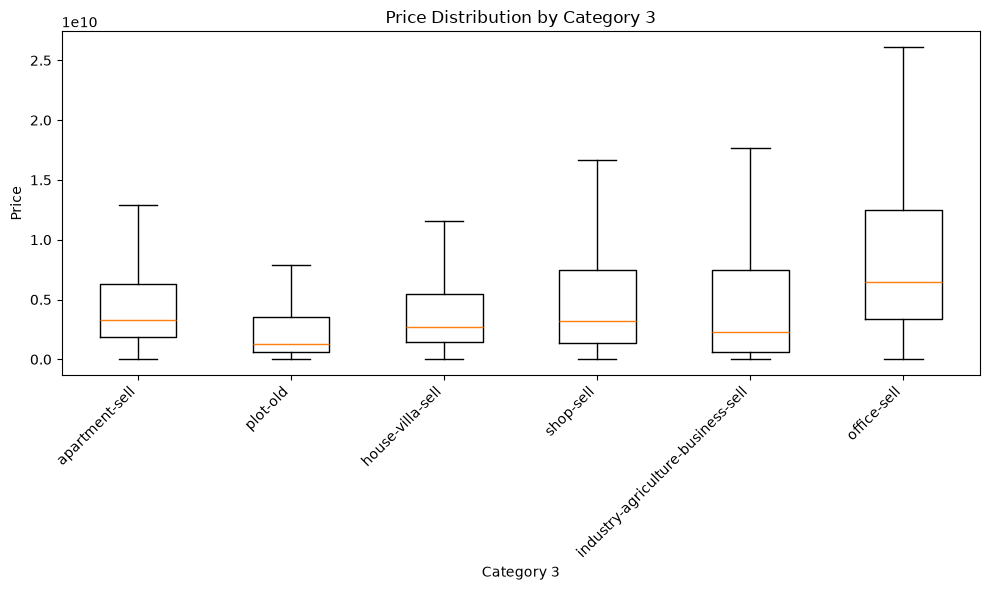

In [6]:
df_sell = df['cat2_slug'].fillna('')
df_sell = df[df['cat2_slug'].str.contains('sell')]
cat3_order = df_sell['cat3_slug'].value_counts().index

df_sell = df_sell[
    (df_sell['price_value'] > 0) &
    (df_sell['price_value'] < 1e11)
]

price_by_cat3 = [
    df_sell[df_sell['cat3_slug'] == cat]['price_value'].dropna().values
    for cat in cat3_order
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(
    price_by_cat3,
    tick_labels=cat3_order,
    showfliers=False
)

ax.set_ylabel('Price')
ax.set_xlabel('Category 3')
ax.set_title('Price Distribution by Category 3')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
این نمودار نشان می‌دهد که قیمت املاک در دسته‌های مختلف سطح سوم تفاوت قابل‌توجهی دارد. دسته‌ی Office بالاترین میانه قیمت را دارد، در حالی که plot-old کمترین میانه را نشان می‌دهد. همچنین پراکندگی قیمت در دسته‌های مختلف متفاوت است و در برخی دسته‌ها دامنه تغییرات قیمت بیشتر است. مقادیر پرت برای خوانایی بهتر در نمودار نمایش داده نشده‌اند.
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
 سوال ۵: رسیم آگهی‌های هر منطقه بر روی نقشه‌ی جغرافیایی heatmap 
</div>

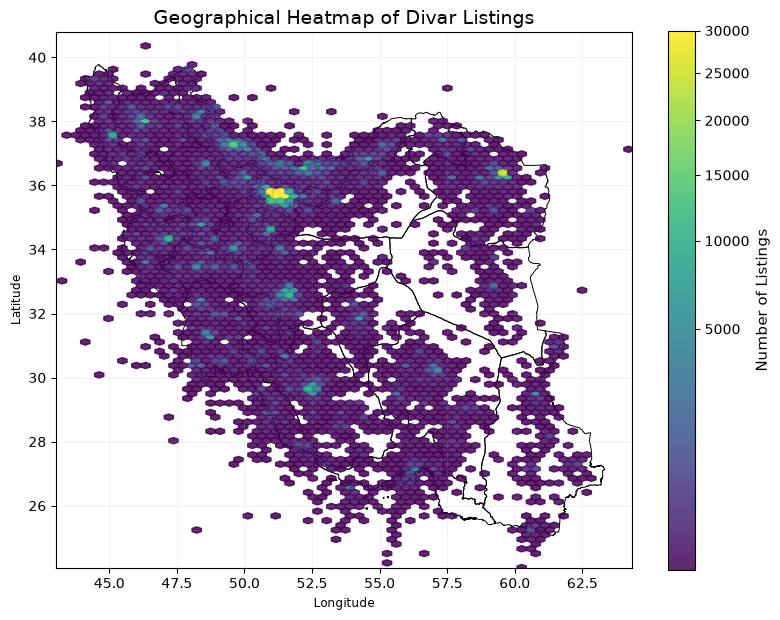

In [ ]:
from matplotlib.colors import PowerNorm
import geopandas as gpd

iran = gpd.read_file(
    "https://raw.githubusercontent.com/ssepehrnoush/Iran-geojson-map-boundaries/master/ir_states_boundaries_coordinates.geojson"
)

map_df = df.dropna(
    subset=['location_latitude', 'location_longitude']
).copy()

fig, ax = plt.subplots(figsize=(8, 8))

iran.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=0.7
)

hb = ax.hexbin(
    map_df['location_longitude'],
    map_df['location_latitude'],
    gridsize=100,
    cmap='viridis',
    mincnt=1,
    norm=PowerNorm(
        gamma=0.45,
        vmin=1,
        vmax=30000
    ),
    alpha=0.85
)

cbar = fig.colorbar(
    hb,
    ax=ax,
    shrink=0.7
)

cbar.set_label(
    'Number of Listings',
    fontsize=11
)

minx, miny, maxx, maxy = iran.total_bounds

ax.set_xlim(minx - 1, maxx + 1)
ax.set_ylim(miny - 1, maxy + 1)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax.set_title(
    'Geographical Heatmap of Divar Listings',
    fontsize=14
)

ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;"> آگهی‌ها عمدتاً در نیمه غربی و شمالی کشور متمرکز هستند و نقشه یک الگوی جغرافیایی روشن نشان می‌دهد. بیشترین تراکم (نقطه زرد و سبز، حدود ۷۰ هزار آگهی) در حوالی طول ۵۱ و عرض ۳۵٫۷ قرار دارد که با تهران مطابقت می‌کند؛ یعنی بازار آگهی به‌شدت متمرکز در پایتخت است و بقیه مناطق در مقایسه با آن تراکم بسیار کمتری دارند (رنگ بنفش تیره، زیر ۱۰ هزار). در مقابل، مناطق مرکزی و شرقی (کویر و بیابان‌های داخلی) تقریباً خالی هستند که با تراکم پایین جمعیت آن نواحی همخوانی دارد. به‌طور کلی توزیع آگهی‌ها با پراکندگی جمعیت و شهرهای بزرگ هم‌راستاست و تهران یک نقطه پرت (outlier) از نظر تعداد است. </div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۶: ترند میانگین قیمت اجاره بر حسب ماه‌های قرار گرفتن آگهی‌ها
</div>

In [ ]:
#Q6

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۷: محاسبه قیمت حقیقی ه ازای میانگین مبلغ قیمت(price_value) در سال‌های ۱۴۰۰ تا ۱۴۰۳ 
</div>

<div dir="rtl" align="right">

در سؤال هفتم از بخش **آمار توصیفی**، افزایش قیمت **اسمی** و **واقعی** ملک در سال‌های ۱۴۰۰ تا ۱۴۰۳ مورد بررسی قرار گرفته است.

برای بررسی این موضوع، محاسبات را به دو روش انجام دادیم؛ یک بار با استفاده از **میانگین قیمت** و بار دیگر با استفاده از **میانه قیمت**. به این ترتیب، تغییرات قیمت در طول این سال‌ها از هر دو منظر بررسی شد.

نکته مهم در تفسیر نتایج این است که تعداد آگهی‌های دارای **قیمت فروش** در سال‌های ۱۴۰۰ و ۱۴۰۱ بسیار کم بوده است. بنابراین، مقادیر به‌دست‌آمده برای این دو سال، به‌ویژه میانگین قیمت، ممکن است نماینده مناسبی از سطح واقعی قیمت بازار نباشند.

به همین دلیل، در نتایج مشاهده می‌شود که از سال ۱۴۰۱ به ۱۴۰۲، **میانگین قیمت اسمی کاهش پیدا می‌کند**. این کاهش لزوماً به معنای کاهش واقعی قیمت ملک در بازار نیست و می‌تواند ناشی از **تعداد بسیار کم آگهی‌های دارای قیمت فروش در سال ۱۴۰۱** و در نتیجه، تأثیرپذیری زیاد میانگین از نمونه محدود موجود باشد.

برای محاسبه **قیمت واقعی**، با توجه به اینکه داده مشخصی برای نرخ تورم سالانه در اختیار نداشتیم، نرخ تورم سالانه را برای تمامی سال‌های مورد بررسی **۵۰ درصد** در نظر گرفتیم و بر اساس آن قیمت‌های اسمی را به قیمت واقعی تبدیل کردیم.

در نهایت، تغییرات قیمت اسمی و واقعی ملک در بازه سال‌های ۱۴۰۰ تا ۱۴۰۳، هم بر اساس **میانگین** و هم بر اساس **میانه** محاسبه و بررسی شد.

</div>



In [ ]:
import jdatetime

#   پایپ‌لاین
def clean_columns(df):
    df.columns = df.columns.str.strip()
    return df


def convert_to_shamsi(df):
    df["created_at_month"] = pd.to_datetime(
        df["created_at_month"], errors="coerce"
    )

    # تبدیل  سال 
    def get_shamsi_year(dt):
        if pd.isna(dt):
            return pd.NA
        return jdatetime.date.fromgregorian(
            year=dt.year, month=dt.month, day=dt.day
        ).year

    # محاسبه سال شمسی
    unique_dates = df["created_at_month"].dropna().unique()
    date_to_shamsi_year = {
        d: get_shamsi_year(pd.Timestamp(d)) for d in unique_dates
    }

    df["Year_Shamsi"] = (
        df["created_at_month"].map(date_to_shamsi_year).astype("Int64")
    )
    return df


def add_real_price(df, inflation_indices):
    inflation_series = df["Year_Shamsi"].map(inflation_indices).fillna(1.0)
    df["Real_Price"] = df["price_value"] / inflation_series
    return df


#  داده‌های ورودی
inflation_indices = {1400: 1.0, 1401: 1.55, 1402: 2.25, 1403: 3.37}

df = pd.read_csv("Divar.csv", low_memory=False)

#  اجرای پایپ‌لاین
final_analysis = (
    df.pipe(clean_columns)
    .pipe(convert_to_shamsi)
    .pipe(add_real_price, inflation_indices=inflation_indices)
    .groupby("Year_Shamsi", as_index=False)[["price_value", "Real_Price"]]
    .mean()
)

#  ترکیب با جدول سال‌ها (نمایش سال‌های خالی)
all_years = pd.DataFrame({"Year_Shamsi": range(1400, 1406)})
result = pd.merge(all_years, final_analysis, on="Year_Shamsi", how="left")

pd.set_option('display.float_format', lambda x: f'{x / 1e9:.2f}B' if pd.notnull(x) else 'NaN')

result = result[result['Year_Shamsi'].between(1400, 1403)]

print(result)

   Year_Shamsi  price_value  Real_Price
0         1400        1.07B       1.07B
1         1401       18.82B      12.14B
2         1402        7.92B       3.52B
3         1403       17.43B       5.17B


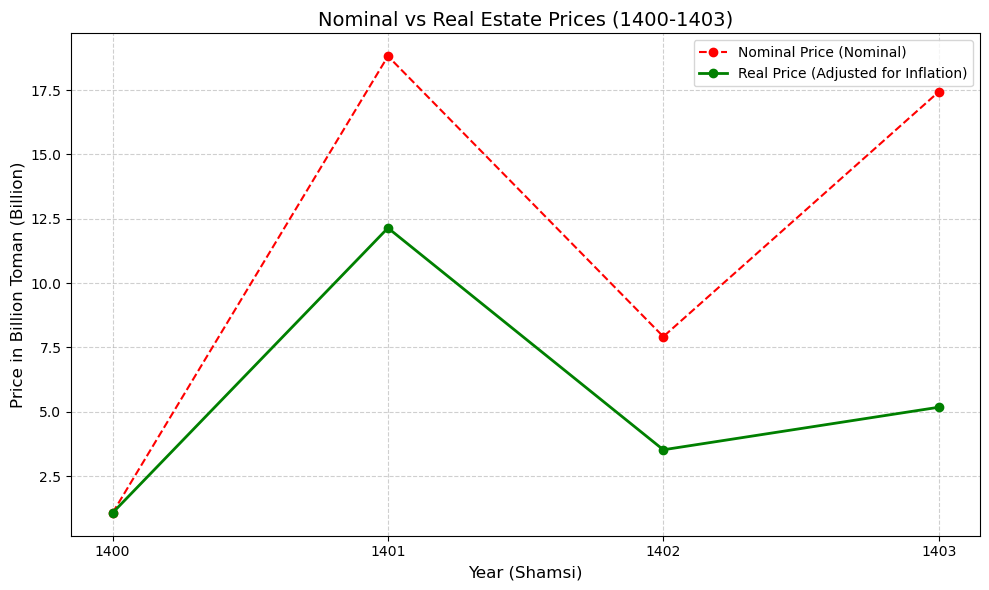

In [ ]:
import matplotlib.pyplot as plt

# حذف سال‌های بدون داده
plot_data = result.dropna(subset=['Real_Price'])

plt.figure(figsize=(10, 6))

# رسم قیمت اسمی
plt.plot(
    plot_data['Year_Shamsi'],
    plot_data['price_value'] / 1e9,
    marker='o',
    color='red',
    linestyle='--',
    label='Nominal Price (Nominal)',
)

# رسم قیمت حقیقی
plt.plot(
    plot_data['Year_Shamsi'],
    plot_data['Real_Price'] / 1e9,
    marker='o',
    color='green',
    linewidth=2,
    label='Real Price (Adjusted for Inflation)',
)

plt.title('Nominal vs Real Estate Prices (1400-1403)', fontsize=14)
plt.xlabel('Year (Shamsi)', fontsize=12)
plt.ylabel('Price in Billion Toman (Billion)', fontsize=12)
plt.xticks(plot_data['Year_Shamsi'].astype(int))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import jdatetime

# ۱. تعریف توابع پایپ‌لاین
def clean_columns(df):
    df.columns = df.columns.str.strip()
    return df


def convert_to_shamsi(df):
    df["created_at_month"] = pd.to_datetime(
        df["created_at_month"], errors="coerce"
    )

    def get_shamsi_year(dt):
        if pd.isna(dt):
            return pd.NA
        return jdatetime.date.fromgregorian(
            year=dt.year, month=dt.month, day=dt.day
        ).year

    # محاسبه سال شمسی 
    unique_dates = df["created_at_month"].dropna().unique()
    date_to_shamsi_year = {
        d: get_shamsi_year(pd.Timestamp(d)) for d in unique_dates
    }

    df["Year_Shamsi"] = (
        df["created_at_month"].map(date_to_shamsi_year).astype("Int64")
    )
    return df


def add_real_price(df, inflation_indices):
    inflation_series = df["Year_Shamsi"].map(inflation_indices).fillna(1.0)
    df["Real_Price"] = df["price_value"] / inflation_series
    return df


# داده‌های ورودی
inflation_indices = {1400: 1.0, 1401: 1.55, 1402: 2.25, 1403: 3.37}

df = pd.read_csv("Divar.csv", low_memory=False)

# اجرای پایپ‌لاین با استفاده از میانه (median) به جای میانگین
final_analysis = (
    df.pipe(clean_columns)
    .pipe(convert_to_shamsi)
    .pipe(add_real_price, inflation_indices=inflation_indices)
    .groupby("Year_Shamsi", as_index=False)[["price_value", "Real_Price"]]
    .median()  # تغییر به میانه برای خنثی‌کردن داده‌های پرت
)

# ترکیب با جدول سال‌ها (نمایش سال‌های خالی)
all_years = pd.DataFrame({"Year_Shamsi": range(1400, 1406)})
result = pd.merge(all_years, final_analysis, on="Year_Shamsi", how="left")

# تنظیم نمایش اعداد 
pd.set_option(
    "display.float_format",
    lambda x: f"{x / 1e9:.2f}B" if pd.notnull(x) else "NaN",
)

result = result[result['Year_Shamsi'].between(1400, 1403)]

print(result)

   Year_Shamsi  price_value  Real_Price
0         1400        1.20B       1.20B
1         1401        2.33B       1.50B
2         1402        2.75B       1.22B
3         1403        2.85B       0.85B


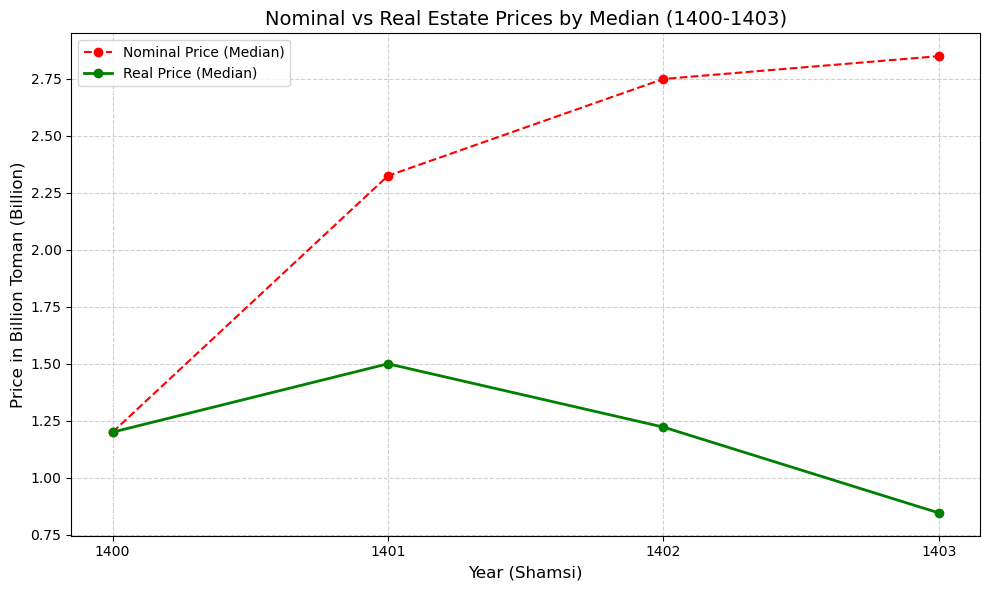

In [ ]:
import matplotlib.pyplot as plt

# حذف سال‌های بدون داده
plot_data = result.dropna(subset=['Real_Price'])

plt.figure(figsize=(10, 6))

# رسم میانه قیمت اسمی و حقیقی
plt.plot(
    plot_data['Year_Shamsi'],
    plot_data['price_value'] / 1e9,
    marker='o',
    color='red',
    linestyle='--',
    label='Nominal Price (Median)',
)

plt.plot(
    plot_data['Year_Shamsi'],
    plot_data['Real_Price'] / 1e9,
    marker='o',
    color='green',
    linewidth=2,
    label='Real Price (Median)',
)

plt.title('Nominal vs Real Estate Prices by Median (1400-1403)', fontsize=14)
plt.xlabel('Year (Shamsi)', fontsize=12)
plt.ylabel('Price in Billion Toman (Billion)', fontsize=12)
plt.xticks(plot_data['Year_Shamsi'].astype(int))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۸: رسم ماتریس هم‌بستگی برای مبلغ قیمت، متراژ زمین، زیربنا، ظرفیت نفرات، تعداد اتاق‌ها و طول و عرض جغرافیایی
</div>

In [ ]:
import seaborn as sns

In [ ]:
divar_df = pd.read_csv('./Divar.csv')

In [ ]:
# handling outliers of price_value, land_size and building size
columns = ['price_value', 'land_size', 'building_size']
for _ in columns: 
    Q1 = divar_df[_].quantile(0.25)
    Q3 = divar_df[_].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    divar_df = divar_df[((divar_df[_] >= lower_bound) & (divar_df[_] <= upper_bound)) | divar_df[_].isna()]

In [ ]:
mapping = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5,
}
divar_df['rooms_count'] = divar_df['rooms_count'].map(mapping).astype(float)

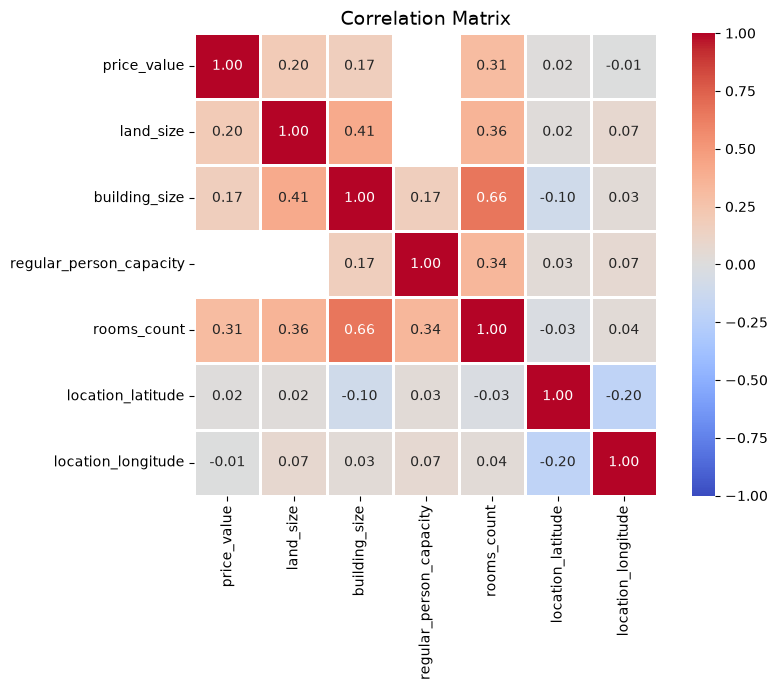

In [ ]:
columns = ['price_value',
        'land_size',
        'building_size',
        'regular_person_capacity',
        'rooms_count',
        'location_latitude',
        'location_longitude']

matrix = divar_df[columns].copy()
corr = matrix.corr(method='pearson')
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.75,
    vmin=-1,
    vmax=1,
)

plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۹: توزیع جغرافیایی خانه‌های دارای امکانات (بالکن، آسانسور، نگهبان، باربیکیو و استخر)
</div>

C:\Users\lenovo\AppData\Local\Temp\ipykernel_21044\3584067184.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('Divar (1).csv')


colum : has_balcony 	 number of available data: 506411
persent of available data 50.6411
persent of true data : 4.086009190163721
colum : has_elevator 	 number of available data: 541749
persent of available data 54.1749
persent of true data : 67.40169340414103
colum : has_pool 	 number of available data: 29390
persent of available data 2.939
persent of true data : 12.660768969037086
colum : has_barbecue 	 number of available data: 31198
persent of available data 3.1198
persent of true data : 25.068914674017567
colum : has_security_guard 	 number of available data: 31312
persent of available data 3.1312
persent of true data : 21.33686765457333
0
0
732417


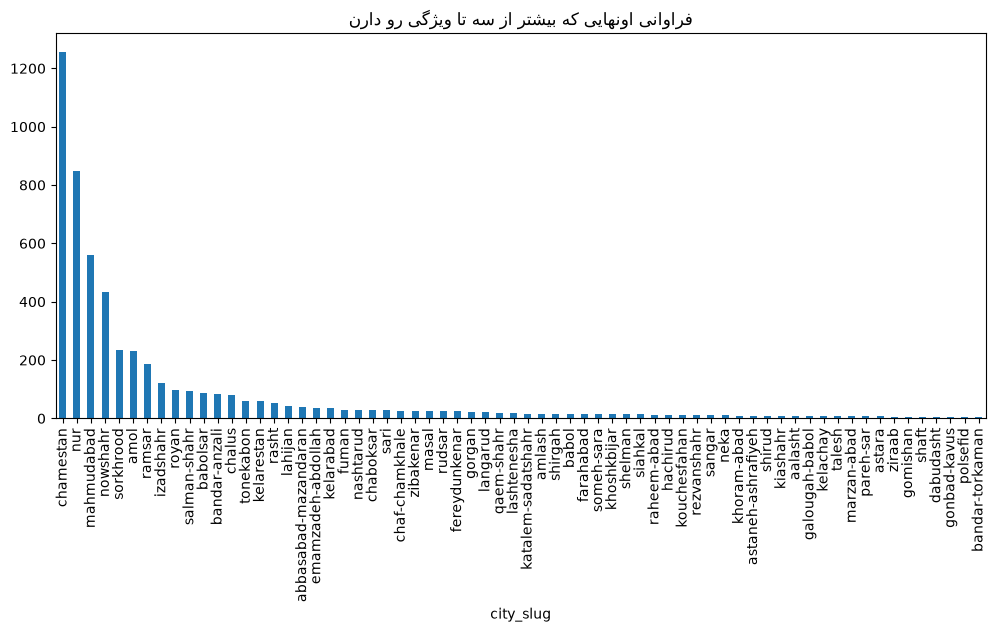

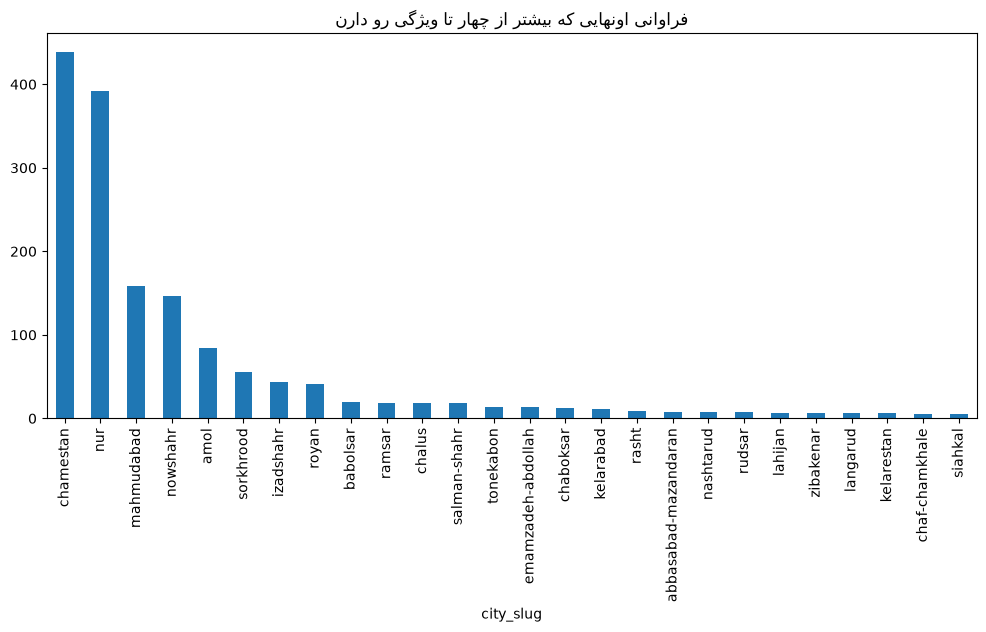

0
396


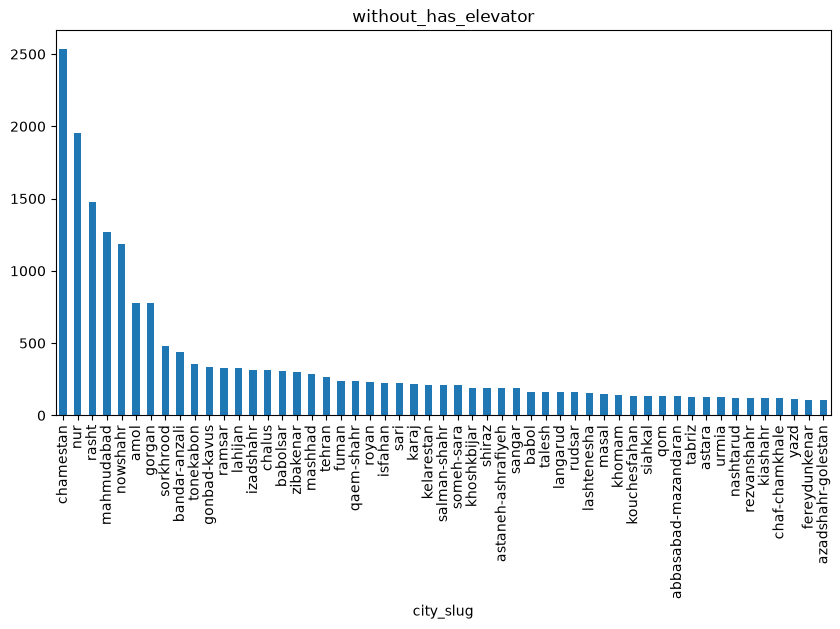

0
0
0


In [ ]:
data = pd.read_csv('Divar (1).csv')
# بررسی کلی دیتا
# data.head()
# # print(data.describe())
# # print(data.info())
# data.sample( 20,random_state=44)
# ----------------------------------------------------------------------------------------------
# بررسی تعداد داده های موجود از هر ستون ودرصد داده های true
feature =['has_balcony','has_elevator','has_pool','has_barbecue','has_security_guard']
for j in feature:
    not_miss=(len(data)-data[j].isnull().sum())
    true=(data[j]==True).sum()
    print('colum :',j,'\t','number of available data:',not_miss)
    print("persent of available data",not_miss/10000)
    print('persent of true data :',(true/not_miss)*100)
# -----------------------------------------------------------------------------------------------
n = data[(data['has_balcony']==True) & (data['has_elevator']==True) & (data['has_pool']==True) & (data['has_barbecue']==True) & (data['has_security_guard']==True) ]
print(len(n))
# هیچ خونه ای که هر پنج ویژگی رو داشته باشه نداشتیم
print(data[feature].notnull().all(axis=1).sum())     
print(data[feature].notnull().any(axis=1).sum())
# پر کردن داده های میس شده با پیش فرض false چون منطقی تر بود
# ساخت ستون جدید برای شمارش تعداد ستون های درست از 5 ستون 
data['n_true'] = data[feature].fillna(False).astype(bool).sum(axis=1)
more_than3 = data[data['n_true']>=3]
more_than3['city_slug'].value_counts().head(10)
count3 = more_than3['city_slug'].value_counts()
count3 = count3[count3>=5]
count3.plot(kind='bar' , figsize=(12,5),title="فراوانی اونهایی که بیشتر از سه تا ویژگی رو دارن")
plt.show()
more_than4 = data[data['n_true']>=4]
more_than4['city_slug'].value_counts().head(10)
count4 = more_than4['city_slug'].value_counts()
count4 = count4[count4>=5]
count4.plot(kind='bar' , figsize=(12,5),title="فراوانی اونهایی که بیشتر از چهار تا ویژگی رو دارن")
plt.show()

for i in feature:
    data_5 = feature.copy()
    data_5.remove(i)
    full = data.dropna(subset=data_5)
    plot_full = full['city_slug'].value_counts()
    print(len(plot_full))
    if len(plot_full)==0 :
        continue
    plot_full = plot_full[plot_full>=100]
    # چون تعداد شهر ها خیلی زیاد بودگفتم فقط بیشتر از 100 تا رو که در واقع فراوون ها هستن نشون بده
    plot_full.plot(kind='bar',figsize=(10,5),title=f"without_{i}")
    plt.show()



 با توجه به اینکه هیچ شهری نبود که هر 5 ویژگی رو باهم داشته باشه و پر کردن داده با 1 کار منطقی نبود چون  مثلا از روی مساحت خونه یا غیره میخواهیم نتیجه گیری کنیم که 
 ممکنه یه خونه مساحت زیادی داشته باشه ولی استخر نداشته باشه با توجه به منطقه هم که خب ما اصلا قراره درباره منطقه خونه نتیجه گیری کنیم و اینجوری انگار پیش فرض 
 خودمون تو نتیجه دخیل بوده پس اون نتیجه دستکاری شده و در عین حال معمولا طبق چیزی که فرض میشه اگر خونه ای ویژگی خاصی رو داشته باشه مالک اون رو ذکر میکنه 
  پس داده های میس شده رو 0 در نظر گرفتم 
  اومدم بار پلات خونه هایی که 4 ویژگی از 5 ویژگی رو داشتن رو رسم کردم و نتیجه به سمت مناطق ویلایی وشمالی رفت بعد برای نتیجه گیری دقیق تر گفتم هربار یه ستون مشخص 
  رو نظر نمیگیریم و توزیع خونه هارو برای چهار تا ویژگی دیگه در نظر میگیرم 
  نتیجه واقعا جالب بود تعداد خونه ها برای اشتراک 4 حالت که ستون اسانسور داخل شون بود صفر شد!!
  اما وقتی کالم اسانسور رو حذف کردم به نتیجه ای مشابه نتیجه جدول اول رسیدم یعنی علت اینکه اشتراک صفر میشد ستون اسانسور بود و بقیه ستون ها باهم اشتراک داشتن و
  نتیجه همون مناطق شمالی ویلایی وتفریحی بود یعنی خونه های موجود تو این مناطق اکثر ان باربیکیو بالکن نگهبان واستخر دارن و عموما اسانسور ندارن و این باعث میشده که 
  اشتراک محدود بشه

In [ ]:
count3.info()
count3.describe()

<class 'pandas.Series'>
Index: 66 entries, chamestan to bandar-torkaman
Series name: count
Non-Null Count  Dtype
--------------  -----
66 non-null     int64
dtypes: int64(1)
memory usage: 3.1+ KB


count      66.00000
mean       80.30303
std       200.05053
min         5.00000
25%         9.00000
50%        16.50000
75%        40.75000
max      1257.00000
Name: count, dtype: float64